In [30]:
# !pip install opencv-python  # (original example - not needed for ToolBench)

# No additional installs needed -- ToolBench data is local JSON files
# loaded with the standard library (json, os) and pandas

In [31]:
import json
import os
import pandas as pd


DATA_DIR = "toolbench"

with open(os.path.join(DATA_DIR, "toolllama_G123_dfs_train.json")) as f:
    train_data = json.load(f)

with open(os.path.join(DATA_DIR, "toolllama_G123_dfs_eval.json")) as f:
    eval_data = json.load(f)


# load API definitions

tools_dir = os.path.join(DATA_DIR, "toolenv", "tools")
categories = sorted([d for d in os.listdir(tools_dir) if not d.startswith(".")])

all_tools = []
for cat in categories:
    cat_path = os.path.join(tools_dir, cat)
    if not os.path.isdir(cat_path):
        continue
    for fname in os.listdir(cat_path):
        fpath = os.path.join(cat_path, fname)
        if fname.endswith(".json") and os.path.isfile(fpath):
            with open(fpath) as f:
                tool = json.load(f)
            tool["_category"] = cat
            all_tools.append(tool)

print(f"\nTool categories: {len(categories)}")
print(f"Total tool definitions loaded: {len(all_tools)}")


def extract_modalities(example):
    """
    Given one ToolBench conversation example, return a dict of modalities.
    """
    modalities = {
        "id": example["id"],
        "user_query": "", # natural language text
        "system_prompt": "", # instructions + tool schemas
        "assistant_thoughts": [], # reasoning chains
        "function_calls": [], # API calls
        "function_responses": [], # API results
    }

    for turn in example["conversations"]:
        role = turn["from"]
        value = turn["value"]
        if role == "system":
            modalities["system_prompt"] = value
        elif role == "user":
            modalities["user_query"] = value
        elif role == "assistant":
            modalities["assistant_thoughts"].append(value)
        elif role == "function":
            modalities["function_responses"].append(value)

    # get function calls from assistant reasoning
    for thought in modalities["assistant_thoughts"]:
        if "Action:" in thought and "Action Input:" in thought:
            try:
                action_line = thought.split("Action:")[1].split("Action Input:")[0].strip()
                action_input = thought.split("Action Input:")[1].strip()
                modalities["function_calls"].append({
                    "action": action_line,
                    "input": action_input,
                })
            except IndexError:
                pass

    return modalities

sample = extract_modalities(train_data[0])
print(f"\n--- Sample modality extraction ---")
print(f"User query: {sample['user_query'][:200]}...")
print(f"Reasoning steps: {len(sample['assistant_thoughts'])}")
print(f"Function calls:  {len(sample['function_calls'])}")
print(f"Function responses: {len(sample['function_responses'])}")

# set up dataframe

records = []
for ex in train_data[:5000]:
    m = extract_modalities(ex)

    # format: "action_name | param1=val1, param2=val2"
    call_strs = []
    for fc in m["function_calls"]:
        try:
            params = json.loads(fc["input"])
            param_str = ", ".join(f"{k}={v}" for k, v in params.items()) if isinstance(params, dict) else fc["input"]
        except (json.JSONDecodeError, AttributeError):
            param_str = fc["input"][:100]
        call_strs.append(f"{fc['action']} | {param_str}")

    resp_strs = []
    for resp_raw in m["function_responses"]:
        try:
            parsed = json.loads(resp_raw)
            if isinstance(parsed, dict):
                # get keys, error status, response preview
                has_error = bool(parsed.get("error", ""))
                resp_content = str(parsed.get("response", ""))
                resp_strs.append(f"error={has_error} | {resp_content[:200]}")
            else:
                resp_strs.append(str(parsed)[:200])
        except json.JSONDecodeError:
            resp_strs.append(resp_raw[:200])

    # read features from function calls
    all_param_keys = []
    for fc in m["function_calls"]:
        try:
            params = json.loads(fc["input"])
            if isinstance(params, dict):
                all_param_keys.extend(params.keys())
        except (json.JSONDecodeError, AttributeError):
            pass

    # red features from function responses
    total_resp_length = sum(len(r) for r in m["function_responses"])
    num_error_responses = 0
    resp_key_counts = []
    for resp_raw in m["function_responses"]:
        try:
            parsed = json.loads(resp_raw)
            if isinstance(parsed, dict):
                if parsed.get("error", ""):
                    num_error_responses += 1
                # Count keys in the nested response
                inner = parsed.get("response", "")
                try:
                    inner_parsed = eval(inner) if isinstance(inner, str) else inner
                    if isinstance(inner_parsed, dict):
                        resp_key_counts.append(len(inner_parsed))
                    elif isinstance(inner_parsed, list):
                        resp_key_counts.append(len(inner_parsed))
                except:
                    resp_key_counts.append(0)
        except json.JSONDecodeError:
            pass

    records.append({
        "id": m["id"],
        "query_length": len(m["user_query"]),
        "num_reasoning_steps": len(m["assistant_thoughts"]),
        "num_function_calls": len(m["function_calls"]),
        "num_function_responses": len(m["function_responses"]),
        "system_prompt_length": len(m["system_prompt"]),
        "user_query": m["user_query"],
        # raw text for each modality (for t-SNE embedding later)
        "function_calls_text": " ;; ".join(call_strs) if call_strs else "",
        "function_responses_text": " ;; ".join(resp_strs) if resp_strs else "",
        "num_unique_params": len(set(all_param_keys)),
        "total_params": len(all_param_keys),
        "total_resp_length": total_resp_length,
        "num_error_responses": num_error_responses,
        "avg_resp_items": np.mean(resp_key_counts) if resp_key_counts else 0,
    })

df = pd.DataFrame(records)
print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Tool categories: 50
Total tool definitions loaded: 10657

--- Sample modality extraction ---
User query: 
I'm conducting a research project on social media influencers, and I'm particularly interested in gathering data from Instagram. Can you help me retrieve user information for a specific username, suc...
Reasoning steps: 3
Function calls:  3
Function responses: 2


<string>:1: SyntaxWarning: "is" with a literal. Did you mean "=="?
<string>:1: SyntaxWarning: "is" with a literal. Did you mean "=="?



DataFrame shape: (5000, 14)
Columns: ['id', 'query_length', 'num_reasoning_steps', 'num_function_calls', 'num_function_responses', 'system_prompt_length', 'user_query', 'function_calls_text', 'function_responses_text', 'num_unique_params', 'total_params', 'total_resp_length', 'num_error_responses', 'avg_resp_items']


,id,query_length,num_reasoning_steps,num_function_calls,num_function_responses,system_prompt_length,user_query,function_calls_text,function_responses_text,num_unique_params,total_params,total_resp_length,num_error_responses,avg_resp_items
0,Step 7: I'm conducting a research project on s...,294,3,3,2,3244,\nI'm conducting a research project on social ...,userinfo_for_instagram_cheapest | username=nik...,"{""error"": """", ""response"": ""{'data': {'user': {...",4,4,1103,0,3.0
1,Step 3: I want to surprise my friends with a b...,706,1,1,0,6924,"This is not the first time you try this task, ...",search_for_open_brewery_db |,,0,0,0,0,0.0
2,Step 2: I am a fashion enthusiast planning a t...,226,1,1,0,5126,\nI am a fashion enthusiast planning a trip to...,l_artistic_directors_for_a_specific_country_fo...,,1,1,0,0,0.0
3,Step 4: My family and I are planning a trip to...,232,2,2,1,3473,\nMy family and I are planning a trip to New Y...,get_half_staff_events_for_given_flag_for_flag_...,"{""error"": """", ""response"": ""[{'flag': 'US', 'is...",1,2,1027,0,0.0
4,Step 4: I'm organizing a cricket event and wou...,274,2,2,1,4900,\nI'm organizing a cricket event and would lik...,fixtures_by_date_for_cricket_live_data | date=...,"{""error"": """", ""response"": ""{'results': [{'id':...",2,2,1027,0,0.0


In [32]:
# Packages (feel free to include more if needed)!
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Distribution

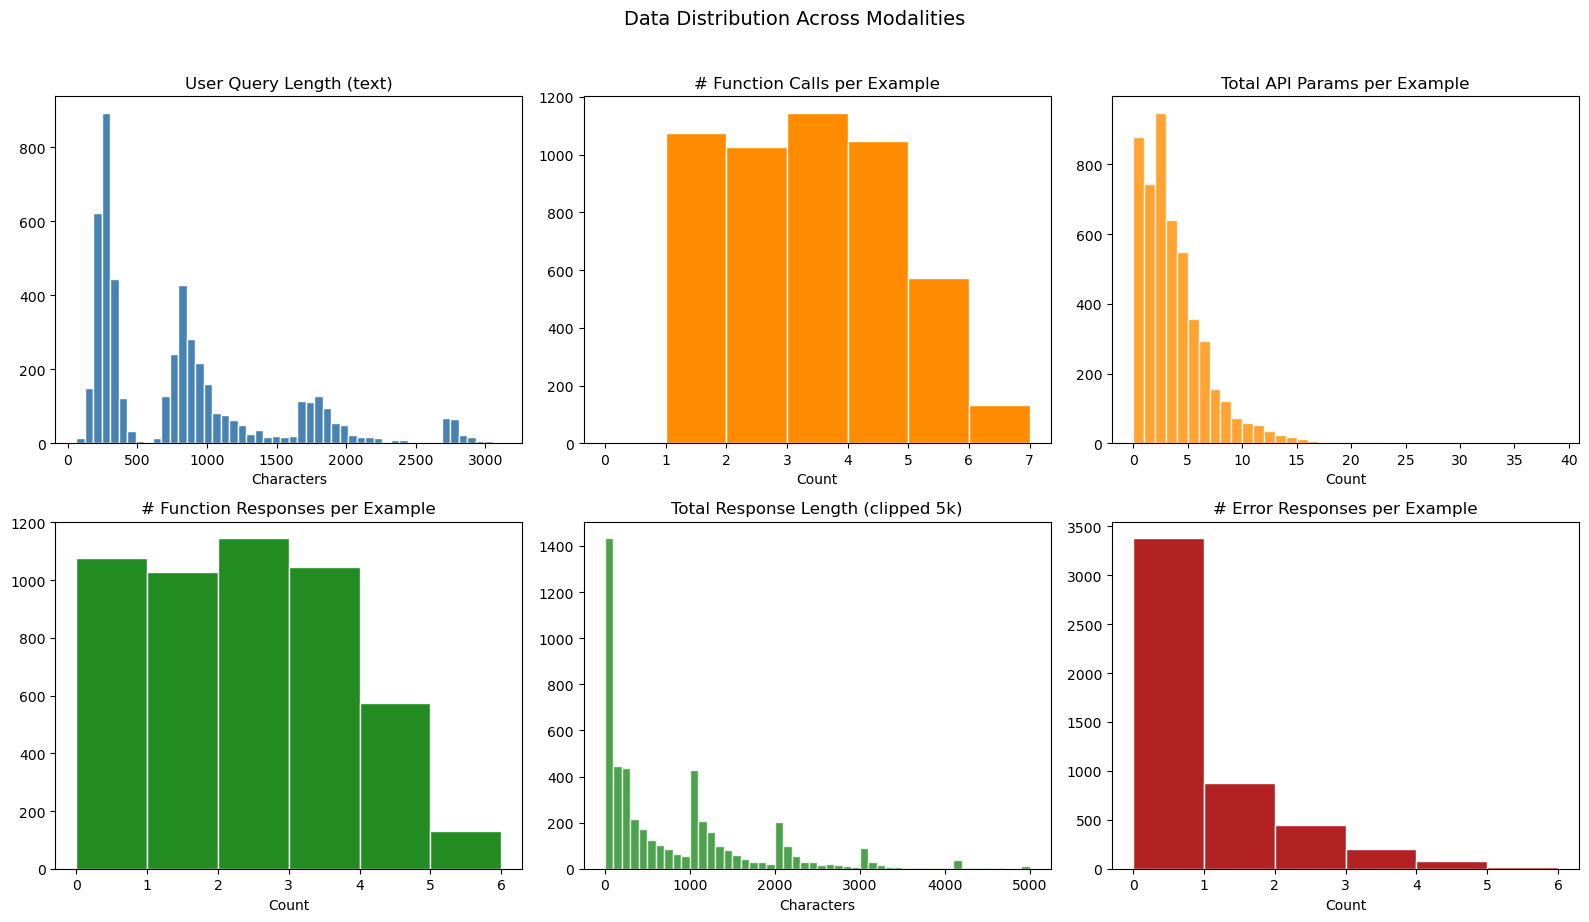

In [33]:
from sklearn.preprocessing import StandardScaler

# Histograms

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Data Distribution Across Modalities", fontsize=14, y=1.02)

# Modality 1: User Queries (natural language)
axes[0, 0].hist(df["query_length"], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("User Query Length (text)")
axes[0, 0].set_xlabel("Characters")

# Modality 2: Function Calls (structured)
axes[0, 1].hist(df["num_function_calls"],
                bins=range(0, df["num_function_calls"].max() + 2),
                color="darkorange", edgecolor="white")
axes[0, 1].set_title("# Function Calls per Example")
axes[0, 1].set_xlabel("Count")

axes[0, 2].hist(df["total_params"],
                bins=range(0, int(df["total_params"].max()) + 2),
                color="darkorange", edgecolor="white", alpha=0.8)
axes[0, 2].set_title("Total API Params per Example")
axes[0, 2].set_xlabel("Count")

# Modality 3: Function Responses (structured)
axes[1, 0].hist(df["num_function_responses"],
                bins=range(0, df["num_function_responses"].max() + 2),
                color="forestgreen", edgecolor="white")
axes[1, 0].set_title("# Function Responses per Example")
axes[1, 0].set_xlabel("Count")

axes[1, 1].hist(df["total_resp_length"].clip(upper=5000), bins=50,
                color="forestgreen", edgecolor="white", alpha=0.8)
axes[1, 1].set_title("Total Response Length (clipped 5k)")
axes[1, 1].set_xlabel("Characters")

axes[1, 2].hist(df["num_error_responses"],
                bins=range(0, int(df["num_error_responses"].max()) + 2),
                color="firebrick", edgecolor="white")
axes[1, 2].set_title("# Error Responses per Example")
axes[1, 2].set_xlabel("Count")

plt.tight_layout()
plt.show()



# Samples



sample 1

Modality 1 - User Query
  
Retrieve the tweets and replies made by Elon Musk. Additionally, get the details of his followers and the user details for the account with the user ID 44196397.
Begin!


Modality 2 - Function Calls
  >> user_tweets_replies_by_screen_name_for_twitter_v2 | username=elonmusk

Modality 3 - Function Responses
  (no function responses)



sample 2

Modality 1 - User Query
  
I am a streamer on Kick.com and I want to enhance my channel. Can you provide me with the details of my channel, including the clips, chatroom, emotes, and livestream info?
Begin!


Modality 2 - Function Calls
  >> get_channel_details_for_kick_com_api_kick_api | channel_name=my_channel
  >> get_channel_clips_for_kick_com_api_kick_api | cursor=initial, channel_name=my_channel
  >> get_channel_chatroom_for_kick_com_api_kick_api | channel_name=my_channel

Modality 3 - Function Responses
  << error=True | <!doctype html>
<html lang=en>
<title>500 Internal Server Error</title>
<h1>Inter

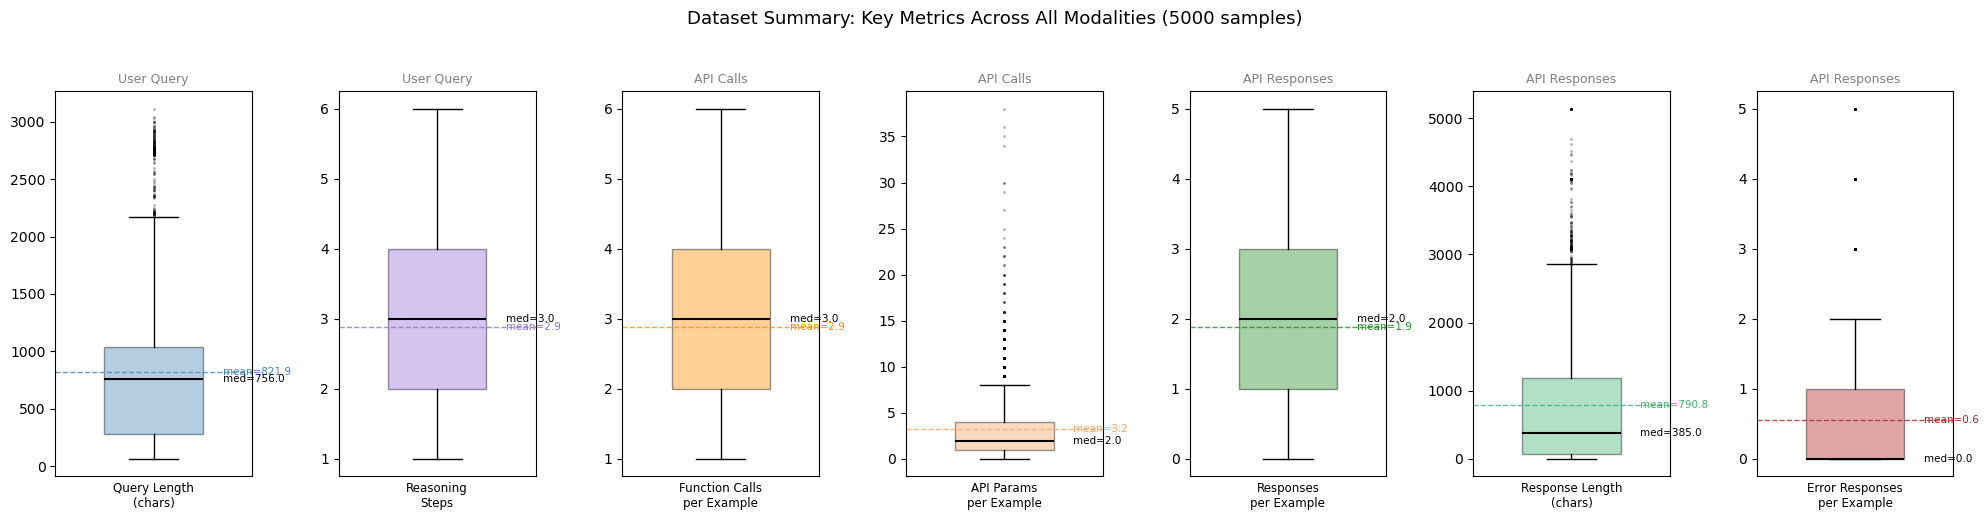

In [34]:
def visualize_samples(data, num_samples=5):
    if num_samples > len(data):
        num_samples = len(data)

    sampled = data.sample(n=num_samples, replace=False, random_state=42)

    for i, (_, row) in enumerate(sampled.iterrows()):
        print(f"\n")
        print(f"sample {i+1}")
        print(f"\nModality 1 - User Query")
        print(f"  {row['user_query'][:300]}{'...' if len(row['user_query']) > 300 else ''}")
        print(f"\nModality 2 - Function Calls")
        if row["function_calls_text"]:
            for call in row["function_calls_text"].split(" ;; "):
                print(f"  >> {call[:200]}")
        else:
            print(f"  (no function calls)")
        print(f"\nModality 3 - Function Responses")
        if row["function_responses_text"]:
            for resp in row["function_responses_text"].split(" ;; "):
                print(f"  << {resp[:200]}")
        else:
            print(f"  (no function responses)")
        print()

# Show 5 concrete samples across all modalities
visualize_samples(df, num_samples=5)

# --- Summary dashboard: each metric gets its own subplot & y-axis ---

metrics = [
    ("Query Length\n(chars)",       df["query_length"],          "steelblue",   "User Query"),
    ("Reasoning\nSteps",            df["num_reasoning_steps"],   "mediumpurple","User Query"),
    ("Function Calls\nper Example", df["num_function_calls"],    "darkorange",  "API Calls"),
    ("API Params\nper Example",     df["total_params"],          "sandybrown",  "API Calls"),
    ("Responses\nper Example",      df["num_function_responses"],"forestgreen", "API Responses"),
    ("Response Length\n(chars)",     df["total_resp_length"],     "mediumseagreen","API Responses"),
    ("Error Responses\nper Example",df["num_error_responses"],   "firebrick",   "API Responses"),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
fig.suptitle("Dataset Summary: Key Metrics Across All Modalities (5000 samples)", fontsize=13, y=1.03)

for ax, (label, series, color, modality) in zip(axes, metrics):
    mean_val = series.mean()
    med_val  = series.median()

    # Box plot for distribution context
    bp = ax.boxplot(series.values, vert=True, widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.4),
                    medianprops=dict(color="black", linewidth=1.5),
                    flierprops=dict(marker=".", markersize=2, alpha=0.3))

    # Annotate mean and median
    ax.axhline(mean_val, color=color, linestyle="--", linewidth=1, alpha=0.8)
    ax.text(1.35, mean_val, f"mean={mean_val:.1f}", fontsize=7.5, color=color, va="center")
    ax.text(1.35, med_val,  f"med={med_val:.1f}", fontsize=7.5, color="black", va="center")

    ax.set_title(f"{modality}", fontsize=9, color="gray")
    ax.set_xlabel(label, fontsize=8.5)
    ax.set_xticks([])

plt.tight_layout()
plt.show()



# Input Distribution

Visualizing Modality 1: User Queries...


/opt/anaconda3/envs/regression_env/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


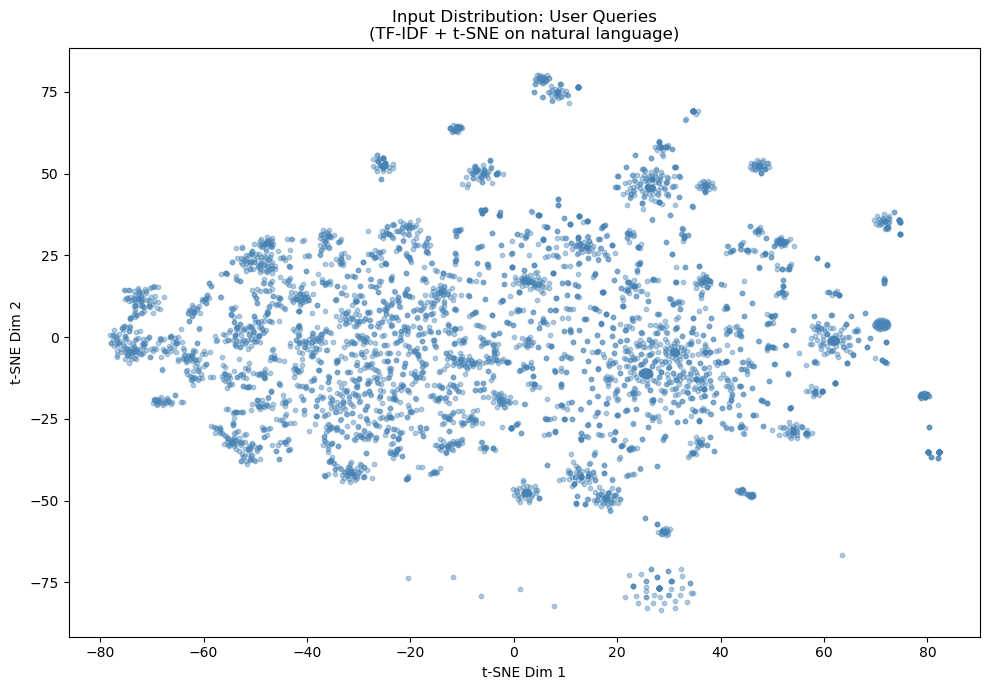

Visualizing Modality 2: Function Calls...


/opt/anaconda3/envs/regression_env/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


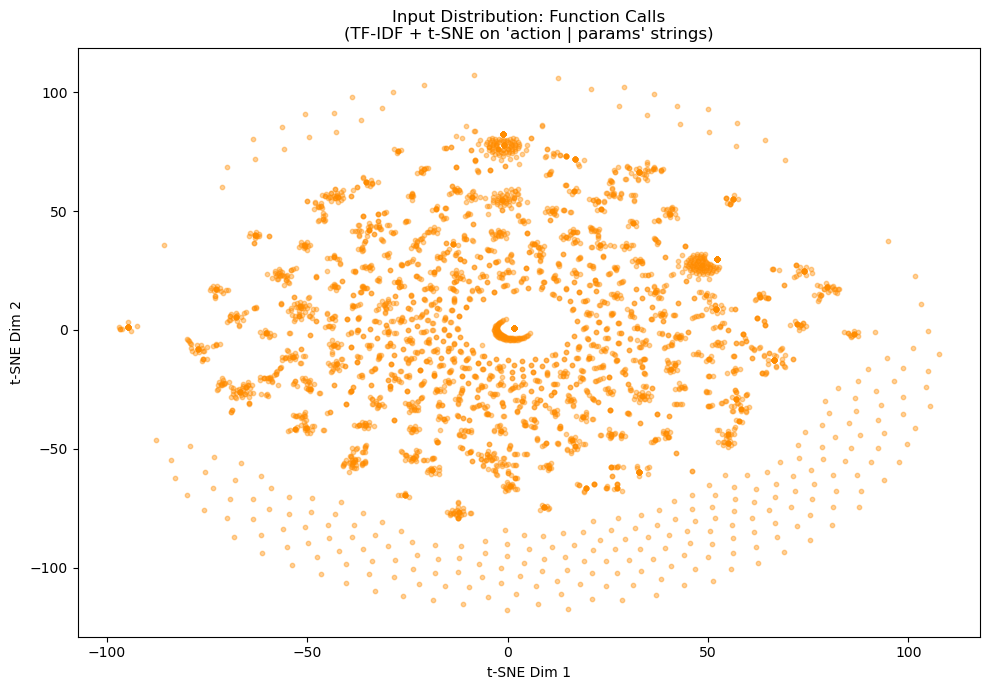

Visualizing Modality 3: Function Responses...


/opt/anaconda3/envs/regression_env/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


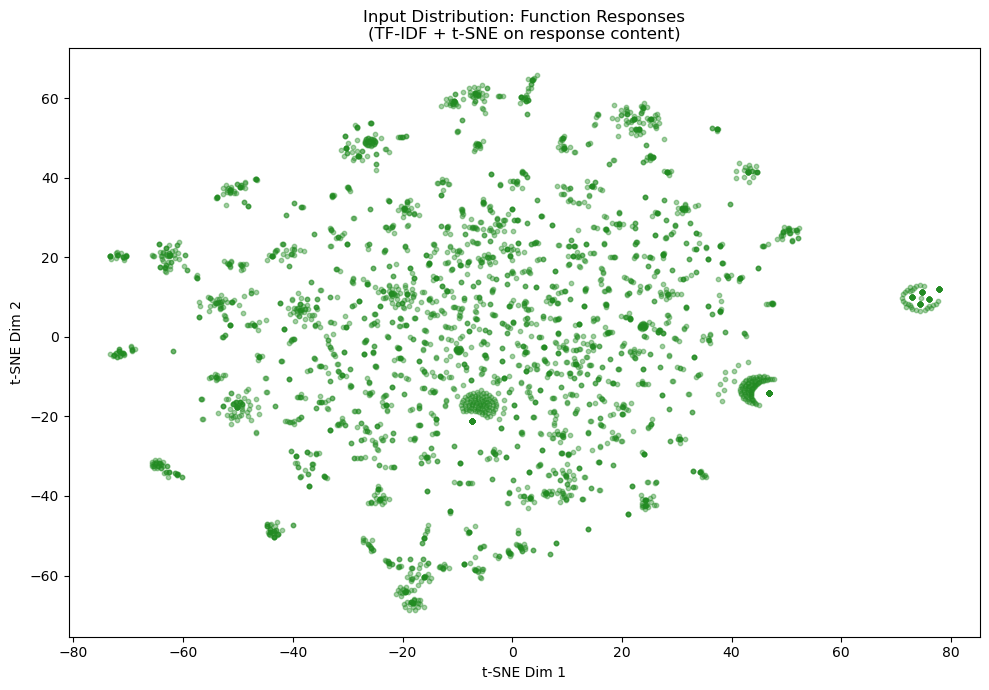

In [35]:
# Separate t-SNE for EACH modality's raw content:

# This shows that each modality occupies a different input space.

def tfidf_tsne(texts, title, color, perplexity=30, n_iter=1000, max_features=500):
    """
    Vectorise a list of strings with TF-IDF, then project to 2D with t-SNE.
    """
    # Filter empty strings
    valid = [t for t in texts if t.strip()]
    if len(valid) < perplexity + 1:
        print(f"  Skipping '{title}': only {len(valid)} non-empty entries (need > {perplexity})")
        return

    vectorizer = TfidfVectorizer(max_features=max_features, stop_words="english",
                                 token_pattern=r"(?u)\b\w[\w./_-]+\b")  # keep API-style tokens
    tfidf_matrix = vectorizer.fit_transform(valid).toarray()

    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=42)
    tsne_result = tsne.fit_transform(tfidf_matrix)

    plt.figure(figsize=(10, 7))
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.4, s=10, c=color)
    plt.title(title)
    plt.xlabel("t-SNE Dim 1")
    plt.ylabel("t-SNE Dim 2")
    plt.tight_layout()
    plt.show()


# Modality 1: User Queries
print("Visualizing Modality 1: User Queries...")
tfidf_tsne(
    df["user_query"].tolist(),
    title="Input Distribution: User Queries\n(TF-IDF + t-SNE on natural language)",
    color="steelblue",
)

# Modality 2: Function Calls
print("Visualizing Modality 2: Function Calls...")
calls_text = df["function_calls_text"].tolist()
tfidf_tsne(
    calls_text,
    title="Input Distribution: Function Calls\n(TF-IDF + t-SNE on 'action | params' strings)",
    color="darkorange",
)

# Modality 3: Function Responses
print("Visualizing Modality 3: Function Responses...")
resp_text = df["function_responses_text"].tolist()
tfidf_tsne(
    resp_text,
    title="Input Distribution: Function Responses\n(TF-IDF + t-SNE on response content)",
    color="forestgreen",
)



In [36]:
# --- 1. Pass Rate ---
# Did the model finish successfully (give_answer) vs. give up (give_up_and_restart)?
# Simple binary success rate across conversations.

def pass_rate(conversations):
    """
    Computes the fraction of conversations where the model
    successfully produced a final answer rather than giving up.

    Args:
        conversations: list of conversation examples (each has 'conversations' key)

    Returns:
        float: pass rate in [0, 1]
    """
    if not conversations:
        raise ValueError("No conversations provided!")

    num_passed = 0
    for ex in conversations:
        for turn in ex["conversations"]:
            if turn["from"] == "assistant" and "give_up_and_restart" not in turn["value"]:
                if "Finish" in turn["value"] and "give_answer" in turn["value"]:
                    num_passed += 1
                    break

    return num_passed / len(conversations)


# --- 2. API Selection F1 ---
# Treats the set of APIs called as predictions vs. ground truth API set.
# Computes precision, recall, and F1.

def api_selection_f1(pred_api_sets, truth_api_sets):
    """
    Computes average precision, recall, and F1 for API selection
    across a batch of examples.

    Args:
        pred_api_sets:  list of sets, each containing predicted API names
        truth_api_sets: list of sets, each containing ground truth API names

    Returns:
        dict with 'precision', 'recall', 'f1' (each averaged over examples)
    """
    if len(pred_api_sets) != len(truth_api_sets):
        raise ValueError("Prediction and ground truth lists must be the same length!")
    if not pred_api_sets:
        raise ValueError("No examples provided!")

    precisions, recalls, f1s = [], [], []

    for pred, truth in zip(pred_api_sets, truth_api_sets):
        if len(pred) == 0 and len(truth) == 0:
            precisions.append(1.0)
            recalls.append(1.0)
            f1s.append(1.0)
            continue

        tp = len(pred & truth)
        precision = tp / len(pred) if len(pred) > 0 else 0.0
        recall    = tp / len(truth) if len(truth) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return {
        "precision": sum(precisions) / len(precisions),
        "recall":    sum(recalls) / len(recalls),
        "f1":        sum(f1s) / len(f1s),
    }


# --- 3. Recall@k for Tool Retrieval ---
# Given a ranked list of retrieved tools, are the correct tools
# in the top k? Directly measures retrieval quality -- the thing
# we want to improve with code-augmented context.

def recall_at_k(ranked_predictions, ground_truths, k=5):
    """
    Computes average Recall@k for tool retrieval across a batch.

    For each example, checks what fraction of the ground truth tools
    appear in the top-k of the ranked prediction list.

    Args:
        ranked_predictions: list of lists, each an ordered list of tool names
                            (most relevant first)
        ground_truths:      list of sets, each containing the correct tool names
        k:                  how many top predictions to consider

    Returns:
        float: average recall@k in [0, 1]
    """
    if len(ranked_predictions) != len(ground_truths):
        raise ValueError("Prediction and ground truth lists must be the same length!")
    if not ranked_predictions:
        raise ValueError("No examples provided!")

    recalls = []
    for ranked, truth in zip(ranked_predictions, ground_truths):
        if len(truth) == 0:
            recalls.append(1.0)
            continue
        top_k = set(ranked[:k])
        hits = len(top_k & truth)
        recalls.append(hits / len(truth))

    return sum(recalls) / len(recalls)


# --- Quick sanity check with dummy data ---
print("=== Metric sanity checks ===")

# Pass rate on first 100 training examples
print(f"Pass rate (first 100 train): {pass_rate(train_data[:100]):.2%}")

# API Selection F1
pred  = [{"api_a", "api_b"}, {"api_c"}, {"api_a"}]
truth = [{"api_a", "api_c"}, {"api_c"}, {"api_a", "api_b"}]
result = api_selection_f1(pred, truth)
print(f"API Selection F1 (dummy): P={result['precision']:.2f}, R={result['recall']:.2f}, F1={result['f1']:.2f}")

# Recall@k
ranked = [
    ["tool_a", "tool_b", "tool_c", "tool_d", "tool_e"],  # truth={tool_a, tool_c} -> 2/2 in top 5
    ["tool_x", "tool_y", "tool_a", "tool_z", "tool_w"],  # truth={tool_a, tool_b} -> 1/2 in top 5
    ["tool_a", "tool_b", "tool_c", "tool_d", "tool_e"],  # truth={tool_f}         -> 0/1 in top 5
]
truth_sets = [{"tool_a", "tool_c"}, {"tool_a", "tool_b"}, {"tool_f"}]
for k_val in [1, 3, 5]:
    print(f"Recall@{k_val} (dummy): {recall_at_k(ranked, truth_sets, k=k_val):.2f}")


=== Metric sanity checks ===
Pass rate (first 100 train): 25.00%
API Selection F1 (dummy): P=0.83, R=0.67, F1=0.72
Recall@1 (dummy): 0.17
Recall@3 (dummy): 0.50
Recall@5 (dummy): 0.50
